## Supplementary Figure 7

Enviorment: env 1

In [1]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import seaborn as sns
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import balanced_accuracy_score
import textwrap


import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import get_test_pr, get_test_roc

In [2]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

In [3]:
es = [13, 9, 3, 3, 3]
all_test_data = []
for pw in np.arange(1, 6):
    e = es[pw - 1]
    test_data = pd.read_csv(f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_resnet/probs/20260724/pw{pw}/model_epoch_{e}_probs.csv")
    test_data = test_data.groupby("id").mean()
    all_test_data.append(test_data)
all_test_data = pd.concat(all_test_data)
all_test_data = all_test_data.groupby("id").mean()
print(len(all_test_data))

66


In [4]:
cases = pd.read_pickle("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_paper_cases.pkl")
controls = pd.read_pickle("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_paper_controls.pkl")
len(cases), len(controls), len(cases + controls),  len(list(set(cases + controls)))

(13, 53, 66, 66)

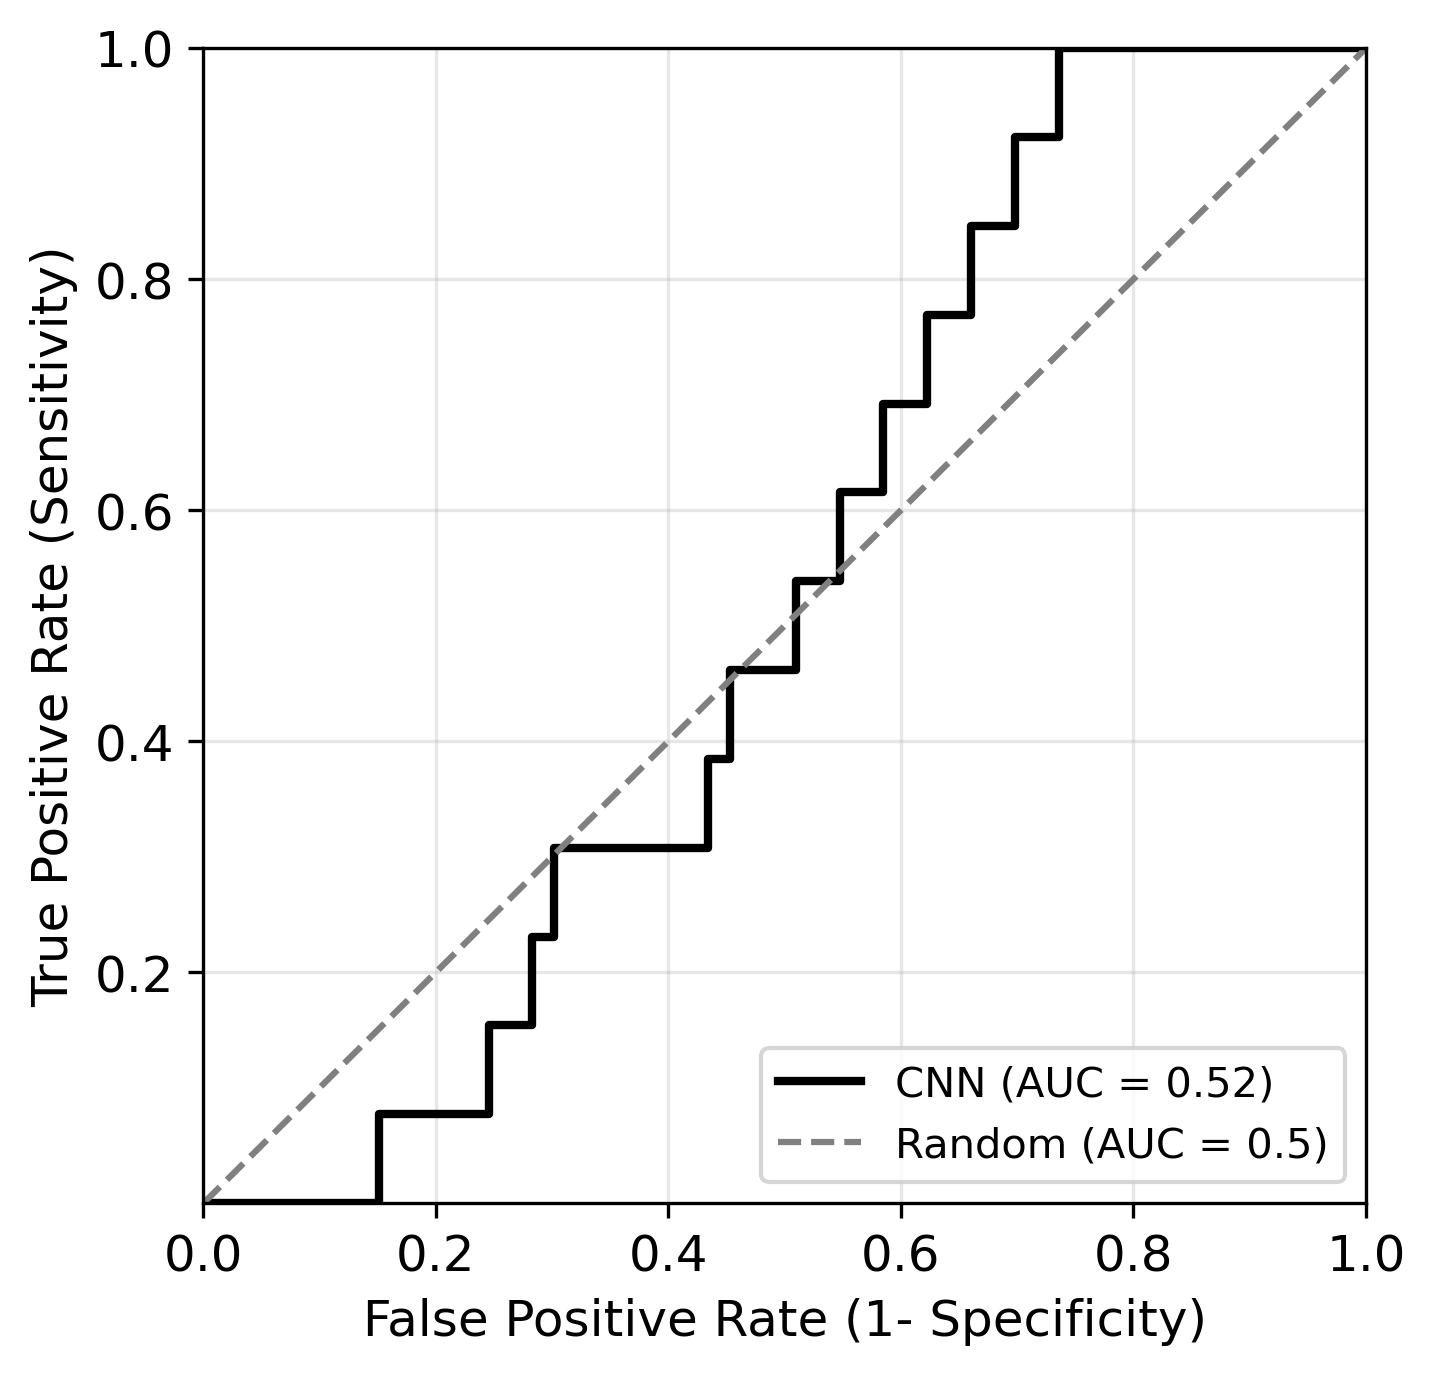

In [5]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# retinal
get_test_roc(all_test_data["label"], all_test_data["prob"], curve_label="CNN", color="black", rand=True)

plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/b_roc.pdf")

plt.show()

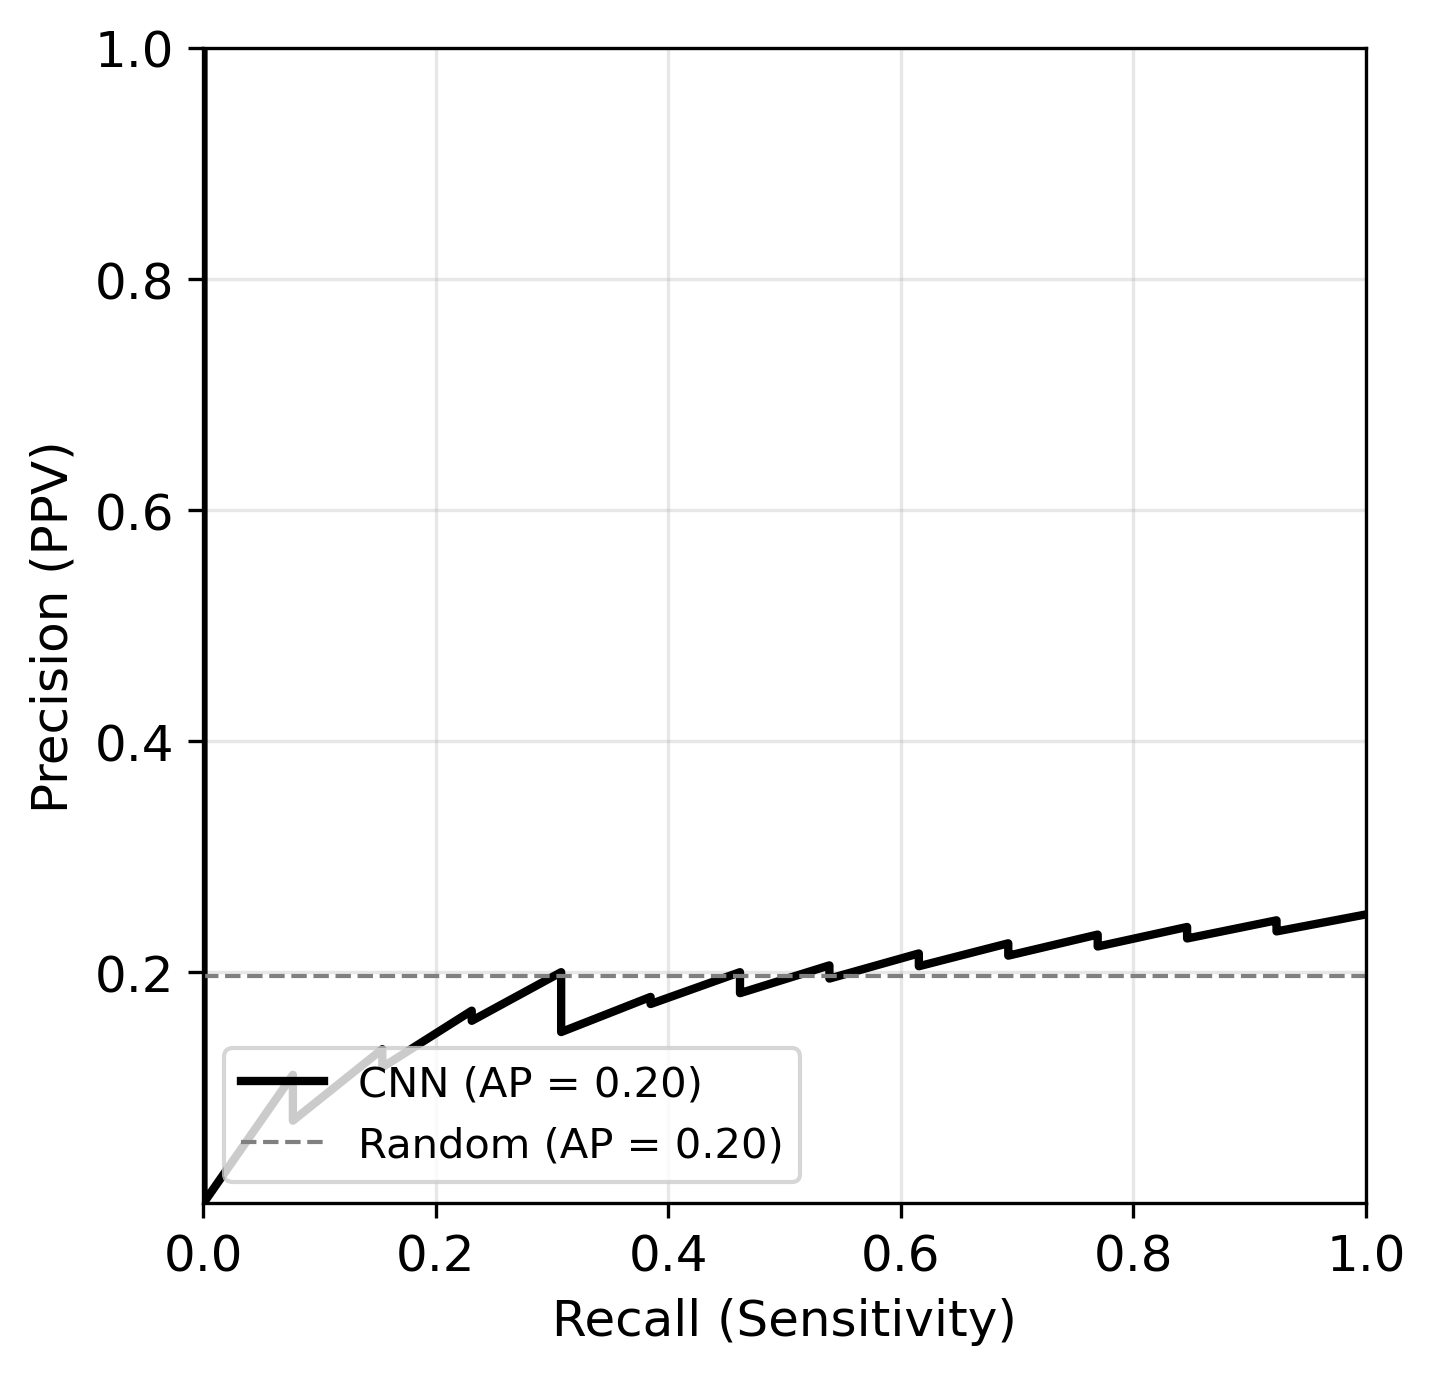

In [6]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# retinal
get_test_pr(all_test_data["label"], all_test_data["prob"], curve_label="CNN", color="black", rand=True)

plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/b_pr.pdf")

plt.show()